In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


Loading the Data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

In [ ]:
print(df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [ ]:
df.shape

(569, 31)

Train Test Split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('diagnosis',axis=1),df['diagnosis'],test_size=0.2,random_state=42)



In [ ]:
x_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,0.3274,1.1940,1.885,17.67,0.009549,0.08606,0.303800,0.033220,0.04197,0.009559,10.31,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,0.6298,0.7629,4.414,81.46,0.004253,0.04759,0.038720,0.015670,0.01798,0.005295,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,0.4098,2.2650,2.608,23.52,0.008738,0.03938,0.043120,0.015600,0.04192,0.005822,10.01,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,0.2497,1.4930,1.497,16.64,0.007189,0.01035,0.010810,0.006245,0.02158,0.002619,12.25,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,0.5158,1.4410,3.312,34.62,0.007514,0.01099,0.007665,0.008193,0.04183,0.005953,11.02,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020


In [ ]:
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train) # Fit used to learn the mean and standard deviation and transform applies the scalar formula (x-mu)/sigma
                                  #output is NumPy array
x_test=scalar.transform(x_test) # it uses the mean  and sigma created for learning dataset to transform test.

x_train = scaler.fit_transform(x_train)

Internally:

Step 1: fit()

scaler.mean_  = computed_mean

scaler.scale_ = computed_std

👉 These are stored inside the scaler object

Step 2: transform()
return transformed_data

👉 This result is assigned to x_train

In [ ]:
x_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

#Labelling the y variable using one hot encoding

In [ ]:
y_train=LabelEncoder().fit_transform(y_train) #label encoder assign the numbers 0,1,2 etc. if value has 3 values then it will assign 0,1,2 which creates ordinal data
                                            # one Hot encoder creates dummy variable
y_test=LabelEncoder().fit_transform(y_test)

In [ ]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

We should do ecnoding after the split because test data may have unseen data which helps to deal with real scenario
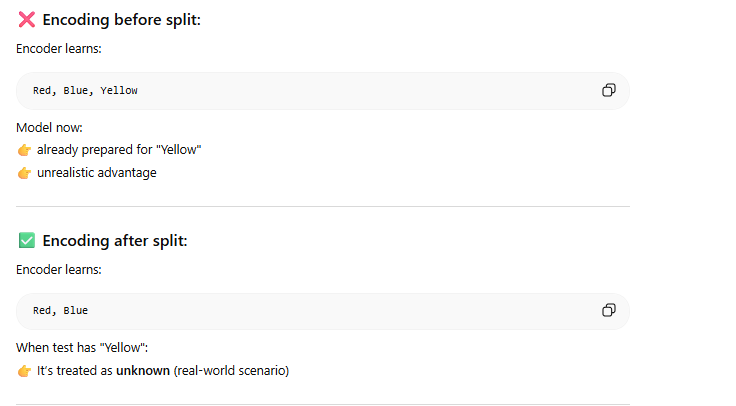

Converting Numpy Array to Tensor

In [ ]:
x_train_tensor=torch.from_numpy(x_train)
y_train_tensor=torch.from_numpy(y_train)
x_test_tensor=torch.from_numpy(x_test)
y_test_tensor=torch.from_numpy(y_test)

In [ ]:
x_train_tensor.shape

torch.Size([455, 30])

Defining the Model

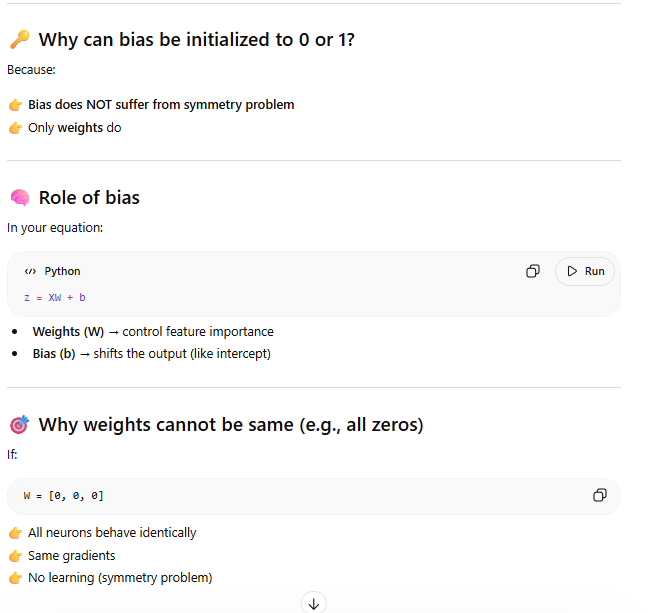

In [ ]:
class MyNN():

  def __init__(self,x):
    self.weights=torch.rand(x.shape[1],1,dtype=torch.float64,requires_grad=True) #it will create matrix of x.shape[1]*1, total weight will be equal to # of feature
    self.bias=torch.zeros(1,dtype=torch.float64,requires_grad=True) ## # of perceptron, since we are creating one perceptron network

  def forward(self,x):
    y= torch.matmul(x,self.weights)+self.bias
    y_pred= torch.sigmoid(y)
    return y_pred

  def loss_function(self, y_pred, y):
    # Clamp predictions to avoid log(0)
    epsilon = 1e-7
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    # Calculate loss
    loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1 - y_pred)).mean() # we are taking mean of the losses
    return loss




# Important Parameter

In [ ]:
learning_rate=0.1
epoch=25

## Training Pipeline


1.   Create Model
2.   Define Loop
  *   Forward pass
  *   Loss Function
*   Backward Pass
*   Parameter update
















In [ ]:
##Creating model

model=MyNN(x_train_tensor)

#creating a loop
for epoch in range(epoch):
  #forward pass
  y_pred=model.forward(x_train_tensor)
  #loss function
  loss=model.loss_function(y_pred,y_train_tensor)

  # backward pass
  loss.backward()

  #Parameter Update
  with torch.no_grad():# we are asking not to track the gradient for this operation
    model.weights -= learning_rate * model.weights.grad
    model.bias -= learning_rate*model.bias.grad

  # Updating the gradient: since grad normally sum the values so we need reset to zero in each epoch
  model.weights.grad.zero_()
  model.bias.grad.zero_()
  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')


Epoch: 1, Loss: 3.401134572824659
Epoch: 2, Loss: 3.2670283005469076
Epoch: 3, Loss: 3.131464645588113
Epoch: 4, Loss: 2.991946912626214
Epoch: 5, Loss: 2.8466669228643275
Epoch: 6, Loss: 2.6941303450518586
Epoch: 7, Loss: 2.5377158861947704
Epoch: 8, Loss: 2.376631803838772
Epoch: 9, Loss: 2.2130400999232154
Epoch: 10, Loss: 2.053961228003567
Epoch: 11, Loss: 1.8966910575303688
Epoch: 12, Loss: 1.7404505657757319
Epoch: 13, Loss: 1.584522918899312
Epoch: 14, Loss: 1.4379016462839673
Epoch: 15, Loss: 1.3059583460814055
Epoch: 16, Loss: 1.1907325112202933
Epoch: 17, Loss: 1.0935733091739155
Epoch: 18, Loss: 1.0146942167725603
Epoch: 19, Loss: 0.9530007739582192
Epoch: 20, Loss: 0.9062848067384558
Epoch: 21, Loss: 0.8716853175025093
Epoch: 22, Loss: 0.8462462700925096
Epoch: 23, Loss: 0.8273607183692424
Epoch: 24, Loss: 0.8129822083801092


# Evaluation

In [ ]:
with torch.no_grad():
  y_pred=model.forward(x_test_tensor)
  y_pred_r=(y_pred > 0.99).float()
  accuracy=(y_pred_r==y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')


Accuracy: 0.6206524968147278


In [ ]:
y_pred_numpy=y_pred.numpy()

In [ ]:
 # Just using accuracy
fpr, tpr, thresholds = roc_curve(y_test, y_pred_numpy)

best_thresh = 0
best_acc = 0

for t in thresholds:
    y_pred = (y_pred_numpy >= t).astype(int)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print(best_thresh)

0.8750997549636037


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_numpy)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold = thresholds[best_idx]

print(best_threshold)

0.24212103263647644


Here’s your **updated 10-line ROC summary with that key internal working added** 👇

1. ROC (Receiver Operating Characteristic) evaluates **binary classification performance across thresholds**.
2. It plots **TPR (Recall)** on Y-axis vs **FPR** on X-axis.
3. TPR = TP / (TP + FN), FPR = FP / (FP + TN).
4. Internally, model probabilities are **sorted in descending order**.
5. Each **unique probability value is treated as a threshold**.
6. For every threshold, predictions are generated and **TPR & FPR are computed**.
7. These values are stored as arrays: `fpr[]`, `tpr[]`, `thresholds[]`.
8. Each index `i` represents one cutoff: `thresholds[i] → (fpr[i], tpr[i])`.
9. A perfect model reaches **top-left (TPR=1, FPR=0)**; diagonal = random (AUC=0.5).
10. Best threshold is often chosen using **Youden’s J (TPR − FPR)** or business criteria.

---

If you want, I can compress this into a **2–3 line ultra-fast interview answer** or turn it into a **visual intuition diagram** 👍
